# 05 — Logistic Regression + Rule Engine

## Frozen ML pipeline

Final synthetic dataset → stratified split → Logistic Regression → probability → deterministic safety rules → LOW / MEDIUM / HIGH.

The on-device model uses only:
- `safe_now`
- `perpetrator_present`
- `can_leave_safely`
- `medical_help`
- `contact_requested`

The 26 DA-WI factors remain the evidence-informed synthetic-data layer. They are not required from the user during the discreet safety interview.

**Important:** performance in this notebook is performance on synthetic/programmatically generated data, not clinical or real-world deployment performance.


In [1]:
# ============================================================
# 0. IMPORTS
# ============================================================

import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    average_precision_score
)

np.random.seed(42)

DATA_PATH = "../data/processed/final_synthetic_risk_dataset.csv"

print("Imports loaded.")


Imports loaded.


## 1. Load the frozen synthetic dataset

In [2]:
df = pd.read_csv(DATA_PATH, encoding="latin1")

print("Shape:", df.shape)
print("Missing values:", df.isna().sum().sum())
display(df.head())


Shape: (20000, 37)
Missing values: 0


,STATE/UT,age,violence_escalation,threat_to_kill,violent_jealousy,recent_separation,lethal_weapon,avoids_arrest,strangulation,illegal_drug_use,...,family_supports_abuse,perpetrator_present,safe_now,can_leave_safely,medical_help,contact_requested,dawi_reference_score,immediate_threat,immediate_safety_risk,severe_ipv_risk
0,Uttar Pradesh,29,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,LOW,0
1,NCT Delhi,39,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,2,0,LOW,0
2,Assam,36,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,4,0,LOW,0
3,West Bengal,24,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,LOW,0
4,Uttar Pradesh,18,0,0,0,0,0,0,1,1,...,0,1,0,0,0,1,7,1,HIGH,0


## 2. Define the exact on-device feature set

In [3]:
MODEL_FEATURES = [
    "safe_now",
    "perpetrator_present",
    "can_leave_safely",
    "medical_help",
    "contact_requested"
]

TARGET = "immediate_safety_risk"

X = df[MODEL_FEATURES].astype(int)
y = df[TARGET].astype(str)

print("Features:", MODEL_FEATURES)
print("Target:", TARGET)

display(y.value_counts(normalize=True))


Features: ['safe_now', 'perpetrator_present', 'can_leave_safely', 'medical_help', 'contact_requested']
Target: immediate_safety_risk


immediate_safety_risk
LOW       0.65805
MEDIUM    0.32090
HIGH      0.02105
Name: proportion, dtype: float64

## 3. Stratified 70/15/15 train-validation-test split

In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nTrain:")
display(y_train.value_counts(normalize=True))
print("\nValidation:")
display(y_val.value_counts(normalize=True))
print("\nTest:")
display(y_test.value_counts(normalize=True))


Train: (14000, 5)
Validation: (3000, 5)
Test: (3000, 5)

Train:


immediate_safety_risk
LOW       0.658071
MEDIUM    0.320857
HIGH      0.021071
Name: proportion, dtype: float64


Validation:


immediate_safety_risk
LOW       0.658
MEDIUM    0.321
HIGH      0.021
Name: proportion, dtype: float64


Test:


immediate_safety_risk
LOW       0.658
MEDIUM    0.321
HIGH      0.021
Name: proportion, dtype: float64

## 4. Train Logistic Regression

In [5]:
ml_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        multi_class="multinomial",
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

ml_pipeline.fit(X_train, y_train)

classifier = ml_pipeline.named_steps["classifier"]

print("Training complete.")
print("Classes:", classifier.classes_)


C:\Users\divya\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Training complete.
Classes: ['HIGH' 'LOW' 'MEDIUM']


## 5. Inspect coefficients

In [6]:
coef_table = pd.DataFrame(
    classifier.coef_,
    index=classifier.classes_,
    columns=MODEL_FEATURES
)

display(coef_table)


,safe_now,perpetrator_present,can_leave_safely,medical_help,contact_requested
HIGH,-5.065349,4.455819,-3.636634,1.813338,-0.140299
LOW,4.819467,-4.235792,4.327973,-2.417660,-0.043734
MEDIUM,0.245882,-0.220026,-0.691339,0.604321,0.184033


## 6. Validation evaluation

In [8]:
val_pred = ml_pipeline.predict(X_val)
val_prob = ml_pipeline.predict_proba(X_val)

print(classification_report(
    y_val,
    val_pred,
    labels=classifier.classes_,
    zero_division=0
))

print("Accuracy:", accuracy_score(y_val, val_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_val, val_pred))


              precision    recall  f1-score   support

        HIGH       1.00      0.98      0.99        63
         LOW       1.00      1.00      1.00      1974
      MEDIUM       1.00      1.00      1.00       963

    accuracy                           1.00      3000
   macro avg       1.00      0.99      1.00      3000
weighted avg       1.00      1.00      1.00      3000

Accuracy: 0.9996666666666667
Balanced accuracy: 0.9947089947089948


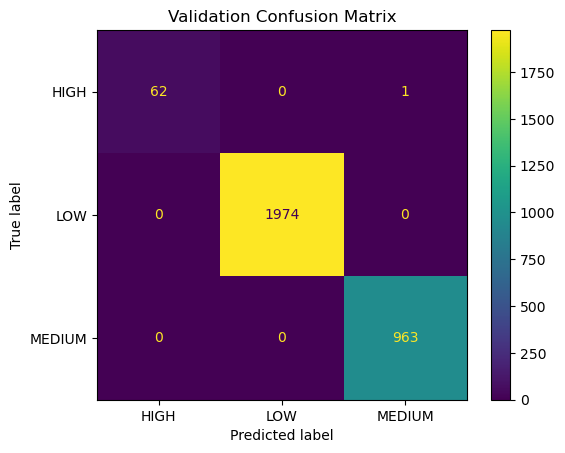

In [9]:
cm_val = confusion_matrix(
    y_val,
    val_pred,
    labels=classifier.classes_
)

ConfusionMatrixDisplay(
    confusion_matrix=cm_val,
    display_labels=classifier.classes_
).plot()

plt.title("Validation Confusion Matrix")
plt.show()


## 7. Final test evaluation

In [10]:
test_pred = ml_pipeline.predict(X_test)
test_prob = ml_pipeline.predict_proba(X_test)

print(classification_report(
    y_test,
    test_pred,
    labels=classifier.classes_,
    zero_division=0
))

print("Accuracy:", accuracy_score(y_test, test_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_test, test_pred))


              precision    recall  f1-score   support

        HIGH       1.00      0.98      0.99        63
         LOW       1.00      1.00      1.00      1974
      MEDIUM       1.00      1.00      1.00       963

    accuracy                           1.00      3000
   macro avg       1.00      0.99      1.00      3000
weighted avg       1.00      1.00      1.00      3000

Accuracy: 0.9996666666666667
Balanced accuracy: 0.9947089947089948


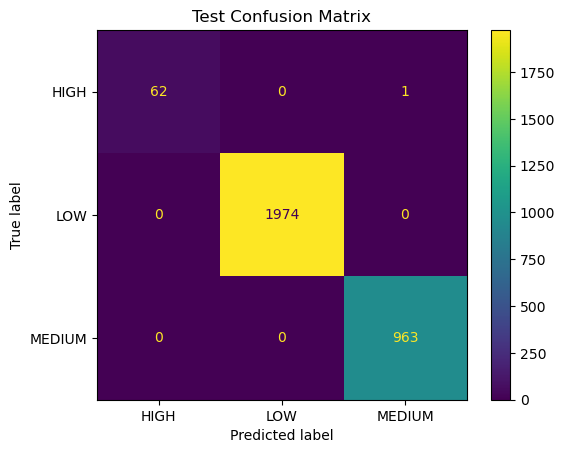

In [11]:
cm_test = confusion_matrix(
    y_test,
    test_pred,
    labels=classifier.classes_
)

ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=classifier.classes_
).plot()

plt.title("Test Confusion Matrix")
plt.show()


## 8. Class-wise metrics — HIGH recall is safety-critical

In [12]:
precision, recall, f1, support = precision_recall_fscore_support(
    y_test,
    test_pred,
    labels=classifier.classes_,
    zero_division=0
)

metrics_table = pd.DataFrame({
    "class": classifier.classes_,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "support": support
})

display(metrics_table)


,class,precision,recall,f1,support
0,HIGH,1.000000,0.984127,0.992000,63
1,LOW,1.000000,1.000000,1.000000,1974
2,MEDIUM,0.998963,1.000000,0.999481,963


## 9. ROC-AUC and PR-AUC diagnostics

In [13]:
y_test_onehot = pd.get_dummies(y_test).reindex(
    columns=classifier.classes_,
    fill_value=0
)

try:
    roc_auc = roc_auc_score(
        y_test_onehot,
        test_prob,
        multi_class="ovr",
        average="macro"
    )
except ValueError:
    roc_auc = np.nan

try:
    pr_auc = average_precision_score(
        y_test_onehot,
        test_prob,
        average="macro"
    )
except ValueError:
    pr_auc = np.nan

print("Macro ROC-AUC:", roc_auc)
print("Macro PR-AUC:", pr_auc)


Macro ROC-AUC: 0.9998965001059767
Macro PR-AUC: 0.9972486124749881


## 10. Deterministic safety rule engine

The ML model provides a probabilistic classification. The rule engine handles explicit current-danger conditions.

HIGH overrides:
1. `safe_now=0 AND perpetrator_present=1 AND can_leave_safely=0`
2. `safe_now=0 AND perpetrator_present=1 AND medical_help=1`
3. `safe_now=0 AND perpetrator_present=1 AND lethal_weapon=1`

`lethal_weapon` is optional because it is not part of the five-question UI. If unavailable, the mobile workflow supplies `0`.


In [14]:
def rule_engine(
    safe_now,
    perpetrator_present,
    can_leave_safely,
    medical_help,
    contact_requested,
    lethal_weapon=0
):
    safe_now = int(safe_now)
    perpetrator_present = int(perpetrator_present)
    can_leave_safely = int(can_leave_safely)
    medical_help = int(medical_help)
    contact_requested = int(contact_requested)
    lethal_weapon = int(lethal_weapon)

    immediate_threat = (
        safe_now == 0 and
        perpetrator_present == 1
    )

    if immediate_threat and can_leave_safely == 0:
        return "HIGH", "CRITICAL_CURRENT_DANGER"

    if immediate_threat and medical_help == 1:
        return "HIGH", "MEDICAL_DANGER"

    if immediate_threat and lethal_weapon == 1:
        return "HIGH", "LETHAL_WEAPON"

    return None, None


## 11. Hybrid ML + rule-engine inference

In [15]:
CLASS_ORDER = list(classifier.classes_)

def predict_risk(
    safe_now,
    perpetrator_present,
    can_leave_safely,
    medical_help,
    contact_requested,
    lethal_weapon=0
):
    row = pd.DataFrame([{
        "safe_now": int(safe_now),
        "perpetrator_present": int(perpetrator_present),
        "can_leave_safely": int(can_leave_safely),
        "medical_help": int(medical_help),
        "contact_requested": int(contact_requested)
    }])

    probabilities = ml_pipeline.predict_proba(row)[0]
    ml_index = int(np.argmax(probabilities))
    ml_risk = CLASS_ORDER[ml_index]
    ml_confidence = float(probabilities[ml_index])

    override_risk, reason = rule_engine(
        safe_now=safe_now,
        perpetrator_present=perpetrator_present,
        can_leave_safely=can_leave_safely,
        medical_help=medical_help,
        contact_requested=contact_requested,
        lethal_weapon=lethal_weapon
    )

    if override_risk is not None:
        return {
            "ml_risk": ml_risk,
            "ml_confidence": ml_confidence,
            "final_risk": override_risk,
            "decision_source": "RULE_OVERRIDE",
            "override_reason": reason
        }

    return {
        "ml_risk": ml_risk,
        "ml_confidence": ml_confidence,
        "final_risk": ml_risk,
        "decision_source": "ML",
        "override_reason": None
    }


## 12. Test representative safety scenarios

In [16]:
test_scenarios = [
    {
        "name": "Safe",
        "safe_now": 1,
        "perpetrator_present": 0,
        "can_leave_safely": 1,
        "medical_help": 0,
        "contact_requested": 0,
        "lethal_weapon": 0
    },
    {
        "name": "Immediate danger + cannot leave",
        "safe_now": 0,
        "perpetrator_present": 1,
        "can_leave_safely": 0,
        "medical_help": 0,
        "contact_requested": 1,
        "lethal_weapon": 0
    },
    {
        "name": "Immediate medical danger",
        "safe_now": 0,
        "perpetrator_present": 1,
        "can_leave_safely": 1,
        "medical_help": 1,
        "contact_requested": 1,
        "lethal_weapon": 0
    },
    {
        "name": "Weapon + immediate threat",
        "safe_now": 0,
        "perpetrator_present": 1,
        "can_leave_safely": 1,
        "medical_help": 0,
        "contact_requested": 1,
        "lethal_weapon": 1
    }
]

results = []

for s in test_scenarios:
    result = predict_risk(**{
        k: v for k, v in s.items()
        if k != "name"
    })
    results.append({"scenario": s["name"], **result})

display(pd.DataFrame(results))


,scenario,ml_risk,ml_confidence,final_risk,decision_source,override_reason
0,Safe,LOW,0.998978,LOW,ML,None
1,Immediate danger + cannot leave,HIGH,0.998557,HIGH,RULE_OVERRIDE,CRITICAL_CURRENT_DANGER
2,Immediate medical danger,HIGH,0.983394,HIGH,RULE_OVERRIDE,MEDICAL_DANGER
3,Weapon + immediate threat,MEDIUM,0.806743,HIGH,RULE_OVERRIDE,LETHAL_WEAPON


## 13. Evaluate the hybrid model on the held-out test set

In [17]:
hybrid_predictions = []

for row in X_test.itertuples(index=False):
    result = predict_risk(
        safe_now=row.safe_now,
        perpetrator_present=row.perpetrator_present,
        can_leave_safely=row.can_leave_safely,
        medical_help=row.medical_help,
        contact_requested=row.contact_requested,
        lethal_weapon=0
    )
    hybrid_predictions.append(result["final_risk"])

hybrid_predictions = np.array(hybrid_predictions)

print(classification_report(
    y_test,
    hybrid_predictions,
    labels=CLASS_ORDER,
    zero_division=0
))

print("Hybrid accuracy:",
      accuracy_score(y_test, hybrid_predictions))

print("Hybrid balanced accuracy:",
      balanced_accuracy_score(y_test, hybrid_predictions))


              precision    recall  f1-score   support

        HIGH       1.00      0.98      0.99        63
         LOW       1.00      1.00      1.00      1974
      MEDIUM       1.00      1.00      1.00       963

    accuracy                           1.00      3000
   macro avg       1.00      0.99      1.00      3000
weighted avg       1.00      1.00      1.00      3000

Hybrid accuracy: 0.9996666666666667
Hybrid balanced accuracy: 0.9947089947089948


In [18]:
ml_high_recall = precision_recall_fscore_support(
    y_test,
    test_pred,
    labels=["HIGH"],
    zero_division=0
)[1][0]

hybrid_high_recall = precision_recall_fscore_support(
    y_test,
    hybrid_predictions,
    labels=["HIGH"],
    zero_division=0
)[1][0]

print("ML HIGH recall:", ml_high_recall)
print("Hybrid HIGH recall:", hybrid_high_recall)


ML HIGH recall: 0.9841269841269841
Hybrid HIGH recall: 0.9841269841269841


## 14. Export model and rule-engine artifacts

In [19]:
MODEL_DIR = "../models"
os.makedirs(MODEL_DIR, exist_ok=True)

MODEL_PATH = f"{MODEL_DIR}/risk_logistic_regression.joblib"
RULE_PATH = f"{MODEL_DIR}/risk_rule_engine.json"
METADATA_PATH = f"{MODEL_DIR}/risk_model_metadata.json"

joblib.dump(
    ml_pipeline,
    MODEL_PATH
)

RULE_SPEC = {
    "version": "1.0",
    "model_features": MODEL_FEATURES,
    "high_overrides": [
        {
            "condition": "safe_now == 0 AND perpetrator_present == 1 AND can_leave_safely == 0",
            "risk": "HIGH",
            "reason": "CRITICAL_CURRENT_DANGER"
        },
        {
            "condition": "safe_now == 0 AND perpetrator_present == 1 AND medical_help == 1",
            "risk": "HIGH",
            "reason": "MEDICAL_DANGER"
        },
        {
            "condition": "safe_now == 0 AND perpetrator_present == 1 AND lethal_weapon == 1",
            "risk": "HIGH",
            "reason": "LETHAL_WEAPON"
        }
    ],
    "fallback": "ML_PREDICTION"
}

with open(RULE_PATH, "w", encoding="utf-8") as f:
    json.dump(RULE_SPEC, f, indent=2)

metadata = {
    "model_type": "multinomial_logistic_regression",
    "features": MODEL_FEATURES,
    "classes": CLASS_ORDER,
    "class_weight": "balanced",
    "random_state": 42,
    "training_data": "synthetic_only",
    "deployment_target": "offline_on_device",
    "rule_engine": "risk_rule_engine.json"
}

with open(METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Saved model:", MODEL_PATH)
print("Saved rules:", RULE_PATH)
print("Saved metadata:", METADATA_PATH)


Saved model: ../models/risk_logistic_regression.joblib
Saved rules: ../models/risk_rule_engine.json
Saved metadata: ../models/risk_model_metadata.json


## Frozen outputs

Notebook 05 produces:

- `models/risk_logistic_regression.joblib`
- `models/risk_rule_engine.json`
- `models/risk_model_metadata.json`

Next stage: **model export/compression and offline mobile inference**.

The final mobile flow is:

**5 discreet answers → local Logistic Regression → rule override → LOW/MEDIUM/HIGH → safety workflow.**
